# Student Depression Dataset - Preprocessing and ANN Model

In this notebook, I prepare the data for a neural network model and build a first simple ANN model using TensorFlow/Keras.

The main steps are:

1. Load the dataset
2. Handle missing values
3. Separate features and target
4. Encode categorical variables
5. Scale numerical variables
6. Split data into train and test sets
7. Build a simple ANN model
8. Train and evaluate the model

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


In [64]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [65]:
possible_paths = [
    Path("../../data/raw/Student Depression Dataset.csv"),
    Path("../../data/Student Depression Dataset.csv"),
    Path("../data/raw/Student Depression Dataset.csv"),
    Path("../data/Student Depression Dataset.csv"),
    Path("Student Depression Dataset.csv"),
]

csv_path = None

for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "CSV file not found. Please check where 'Student Depression Dataset.csv' is saved."
    )

df = pd.read_csv(csv_path)

print(f"Dataset loaded from: {csv_path}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded from: ..\..\data\Student Depression Dataset.csv
Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [67]:
df.isnull().sum().sort_values(ascending=False).head(10)

Financial Stress                         3
id                                       0
Gender                                   0
Family History of Mental Illness         0
Work/Study Hours                         0
Have you ever had suicidal thoughts ?    0
Degree                                   0
Dietary Habits                           0
Sleep Duration                           0
Job Satisfaction                         0
dtype: int64

In [68]:
df_model = df.copy()

df_model = df_model.drop(columns=["id"])

df_model.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [69]:
target_col = "Depression"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27901, 16)
y shape: (27901,)


In [70]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

Categorical features:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (22320, 16)
X_test: (5581, 16)
y_train distribution:
Depression
1    0.585
0    0.415
Name: proportion, dtype: float64

y_test distribution:
Depression
1    0.586
0    0.414
Name: proportion, dtype: float64


In [72]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [73]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (22320, 111)
Processed X_test shape: (5581, 111)


In [74]:
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print(type(X_train_processed))
print(X_train_processed.shape)

<class 'numpy.ndarray'>
(22320, 111)


In [75]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

In [76]:
input_dim = X_train_processed.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,129 (16.13 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8192 - loss: 0.4035 - val_accuracy: 0.8401 - val_loss: 0.3614
Epoch 2/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8490 - loss: 0.3481 - val_accuracy: 0.8407 - val_loss: 0.3609
Epoch 3/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step - accuracy: 0.8503 - loss: 0.3455 - val_accuracy: 0.8409 - val_loss: 0.3611
Epoch 4/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8518 - loss: 0.3433 - val_accuracy: 0.8416 - val_loss: 0.3611
Epoch 5/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8519 - loss: 0.3412 - val_accuracy: 0.8414 - val_loss: 0.3612
Epoch 6/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8525 - loss: 0.3390 - val_accuracy: 0.8418 - val_loss: 0.3616
Epoch 7/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8541 - loss: 0.3367 - val_accuracy: 0.8412 - val_loss: 0.3625
Epoch 8/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.8547 - loss: 0.3341 - val_accuracy

In [78]:
history_df = pd.DataFrame(history.history)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.819220,0.403528,0.840054,0.361391
1,0.849014,0.348131,0.840726,0.360877
2,0.850302,0.345455,0.840950,0.361088
3,0.851759,0.343320,0.841622,0.361114
4,0.851871,0.341196,0.841398,0.361174


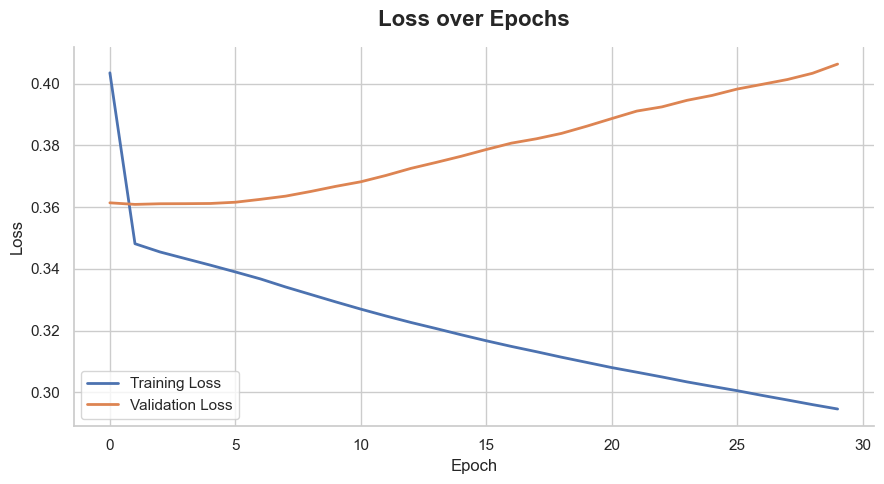

In [79]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["loss"], label="Training Loss", linewidth=2)
plt.plot(history_df["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Loss over Epochs", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

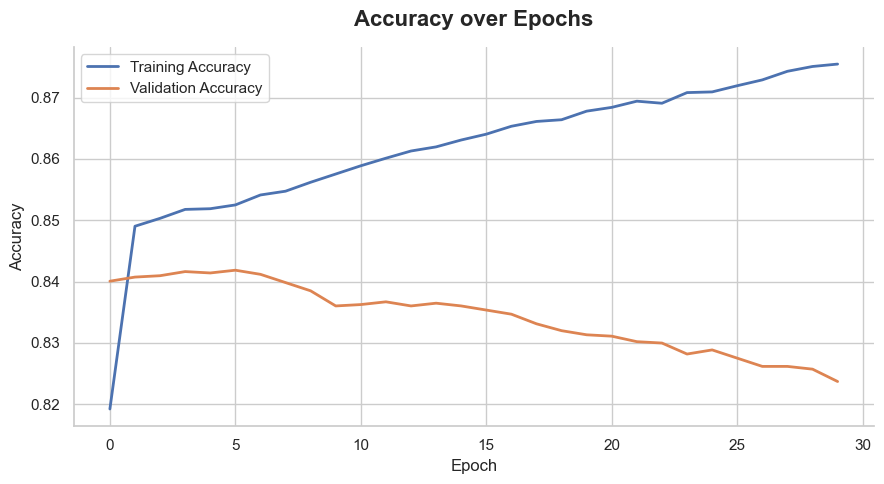

In [80]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Accuracy over Epochs", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [81]:
y_pred_proba = model.predict(X_test_processed).ravel()

y_pred = (y_pred_proba >= 0.5).astype(int)

print("First 10 predicted probabilities:")
print(y_pred_proba[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step
First 10 predicted probabilities:
[0.9772155  0.7802963  0.78401697 0.09943662 0.314299   0.01101309
 0.31776717 0.86936295 0.01072266 0.9938929 ]

First 10 predicted classes:
[1 1 1 0 0 0 0 1 0 1]


In [82]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Score": [accuracy, precision, recall, f1, roc_auc, avg_precision]
})

results

,Metric,Score
0,Accuracy,0.832288
1,Precision,0.851628
2,Recall,0.864137
3,F1-score,0.857837
4,ROC-AUC,0.907033
5,Average Precision,0.926472


In [83]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2313
           1       0.85      0.86      0.86      3268

    accuracy                           0.83      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.83      0.83      0.83      5581



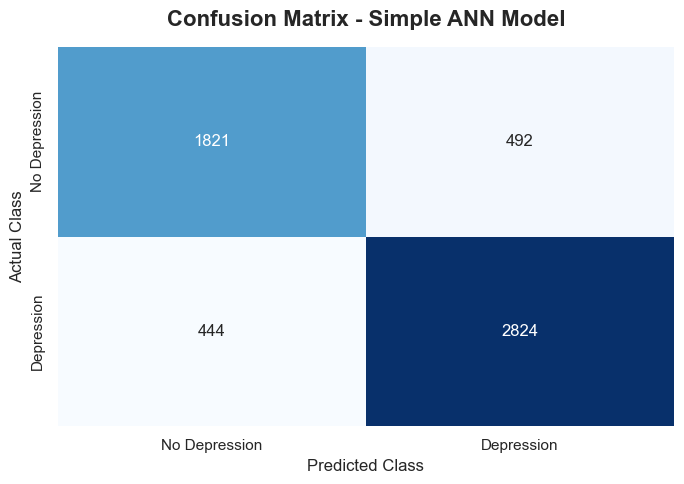

In [84]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Depression", "Depression"],
    yticklabels=["No Depression", "Depression"]
)

plt.title("Confusion Matrix - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

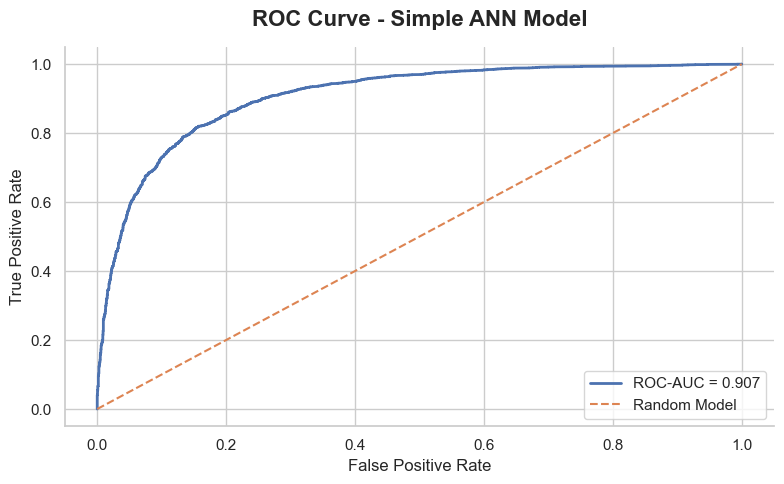

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Model")

plt.title("ROC Curve - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

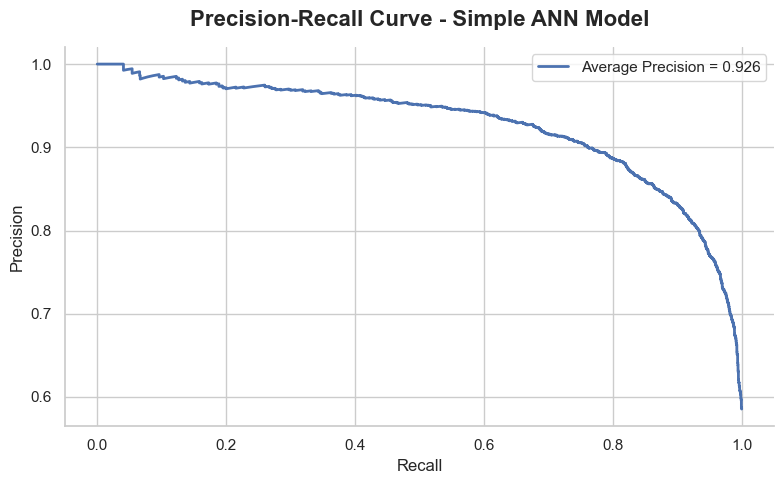

In [86]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))

plt.plot(recall_curve, precision_curve, linewidth=2, label=f"Average Precision = {avg_precision:.3f}")

plt.title("Precision-Recall Curve - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

## Simple ANN Model Interpretation

The simple ANN model performs well as a baseline model.

The model reaches an accuracy of around 83.2%, with a recall of around 86.4% for the depression class. The ROC-AUC score is around 0.91, which shows that the model has a good ability to separate students with and without depression.

The confusion matrix shows that the model correctly predicts many students in both classes. However, it also has false negatives, meaning that some students with depression are predicted as not depressed.

In a mental health context, false negatives are important because they represent possible risk cases that the model misses.

The training curves show signs of overfitting. The training loss continues to decrease while the validation loss increases. This means the model becomes better on the training data but does not generalize as well to unseen validation data.

To improve the model, the next step is to use regularization methods such as Dropout, L2 regularization and EarlyStopping.

In [87]:
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [88]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

In [89]:
input_dim = X_train_processed.shape[1]

improved_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.3),
    
    layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [91]:
improved_history = improved_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8247 - loss: 0.4743 - val_accuracy: 0.8412 - val_loss: 0.4110
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8473 - loss: 0.4009 - val_accuracy: 0.8441 - val_loss: 0.3914
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8486 - loss: 0.3842 - val_accuracy: 0.8418 - val_loss: 0.3828
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8493 - loss: 0.3741 - val_accuracy: 0.8425 - val_loss: 0.3790
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8497 - loss: 0.3703 - val_accuracy: 0.8401 - val_loss: 0.3763
Epoch 6/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8514 - loss: 0.3666 - val_accuracy: 0.8418 - val_loss: 0.3729
Epoch 7/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.3647 - val_accuracy: 0.8439 - val_loss: 0.3720
Epoch 8/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - loss: 0.3638 - val_accuracy: 0.

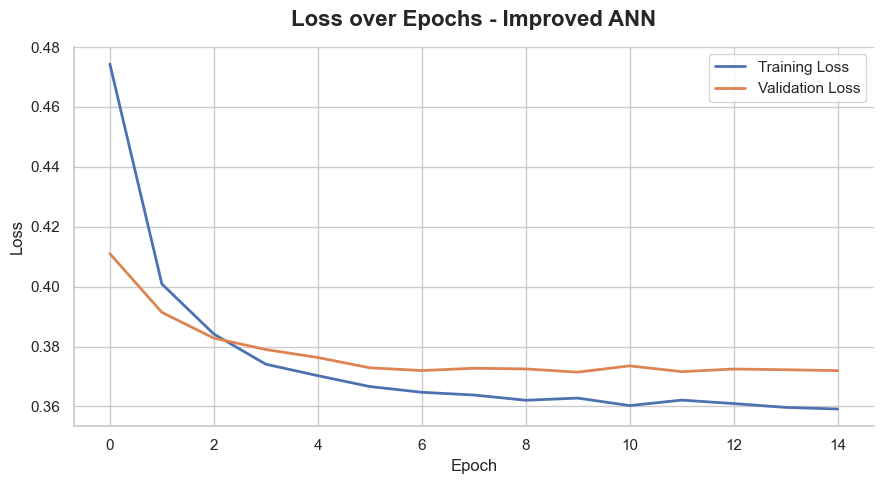

In [92]:
improved_history_df = pd.DataFrame(improved_history.history)

plt.figure(figsize=(9, 5))

plt.plot(improved_history_df["loss"], label="Training Loss", linewidth=2)
plt.plot(improved_history_df["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Loss over Epochs - Improved ANN", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

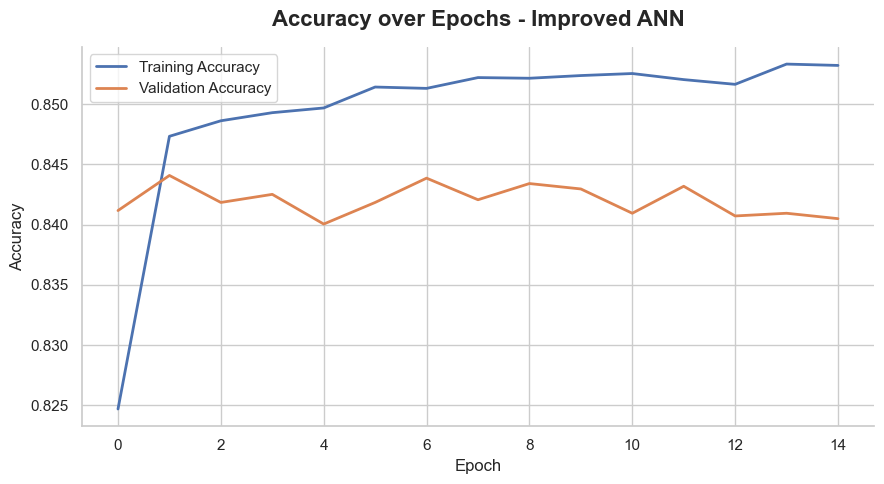

In [93]:
plt.figure(figsize=(9, 5))

plt.plot(improved_history_df["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(improved_history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Accuracy over Epochs - Improved ANN", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [94]:
y_pred_proba_improved = improved_model.predict(X_test_processed).ravel()
y_pred_improved = (y_pred_proba_improved >= 0.5).astype(int)

improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)
improved_roc_auc = roc_auc_score(y_test, y_pred_proba_improved)
improved_avg_precision = average_precision_score(y_test, y_pred_proba_improved)

improved_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Simple ANN": [accuracy, precision, recall, f1, roc_auc, avg_precision],
    "Improved ANN": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_roc_auc,
        improved_avg_precision
    ]
})

improved_results

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Metric,Simple ANN,Improved ANN
0,Accuracy,0.832288,0.843576
1,Precision,0.851628,0.860584
2,Recall,0.864137,0.874541
3,F1-score,0.857837,0.867506
4,ROC-AUC,0.907033,0.917493
5,Average Precision,0.926472,0.936233


## Model Comparison: Simple ANN vs Improved ANN

The improved ANN model performs better than the simple ANN model on most evaluation metrics.

The accuracy increases from around 82.9% to 84.3%. The ROC-AUC also improves from around 0.90 to 0.92, which means that the improved model has a stronger ability to separate students with and without depression.

The most important improvement is recall for the depression class. The improved model reaches a recall of around 90%, compared to around 87% for the simple ANN. This means that the improved model identifies more students with depression.

In a mental health context, recall is especially important because false negatives mean that students with depression are predicted as not depressed. Therefore, the improved ANN model is more suitable from a risk-detection perspective.

Precision is almost the same between the two models. The improved model has slightly more false positives, but this may be acceptable in a student wellbeing context because it is often better to flag a possible risk than to miss a student who may need support.

Overall, the improved ANN model is selected as the better model because it has higher recall, higher F1-score, higher ROC-AUC and better generalization.

In [95]:
print(classification_report(y_test, y_pred_improved))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2313
           1       0.86      0.87      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



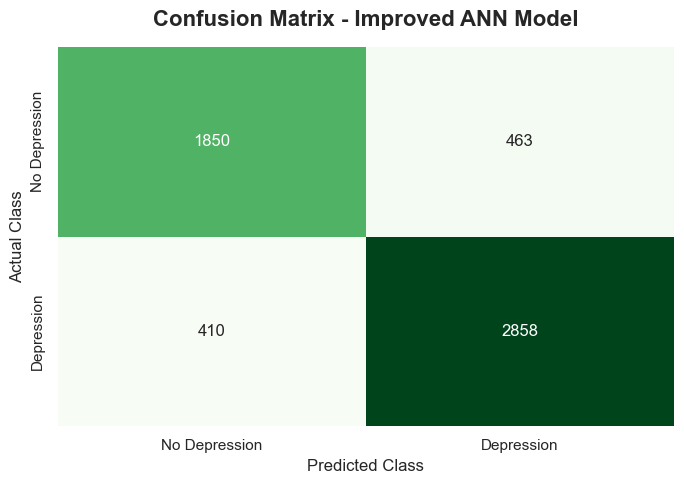

In [96]:
cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["No Depression", "Depression"],
    yticklabels=["No Depression", "Depression"]
)

plt.title("Confusion Matrix - Improved ANN Model", weight="bold", pad=15)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Improved ANN Model Interpretation

The improved ANN model uses Dropout, L2 regularization and EarlyStopping to reduce overfitting.

Compared to the simple ANN model, the improved model has better overall performance. Accuracy increases from around 83.2% to 84.4%, and the ROC-AUC score increases from around 0.91 to 0.92.

The improved model also reduces the number of false negatives from 444 to 410. This means that it misses fewer students in the depression class compared to the baseline model.

The validation curves are more stable than in the simple ANN model. The gap between training and validation performance is smaller, which indicates better generalization.

The improved model is therefore better than the simple ANN model, especially because it has higher recall, higher F1-score and fewer false negatives.

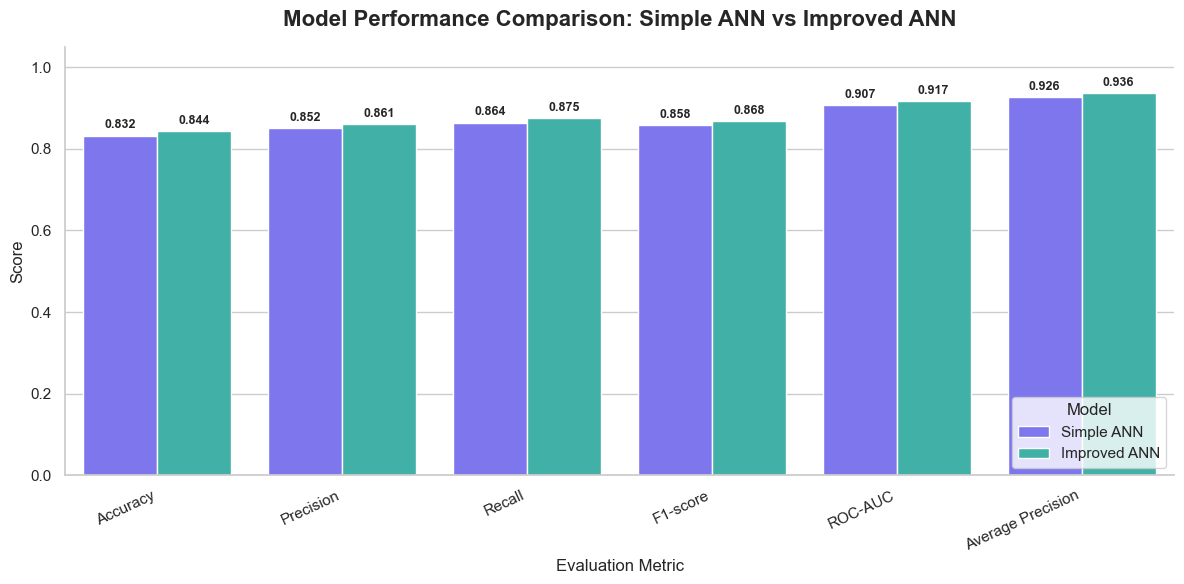

In [97]:
comparison_plot_df = improved_results.melt(
    id_vars="Metric",
    value_vars=["Simple ANN", "Improved ANN"],
    var_name="Model",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#6C63FF", "#2EC4B6"]
)

plt.title("Model Performance Comparison: Simple ANN vs Improved ANN", weight="bold", pad=15)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=25, ha="right")
plt.legend(title="Model", loc="lower right")

# Add labels only on real bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

## Model Comparison: Simple ANN vs Improved ANN

The improved ANN model performs better than the simple ANN model on most evaluation metrics.

Accuracy improves from around 0.832 to 0.844. Precision, recall, F1-score, ROC-AUC and Average Precision also improve.

The recall for the depression class improves from around 0.864 to 0.875. This means that the improved model identifies more students in the depression class.

The confusion matrix also shows that false negatives decrease from 444 to 410. In a mental health context, this is important because false negatives represent students with depression who are predicted as not depressed.

Overall, the improved ANN model is selected as a better model than the simple ANN because it has stronger generalization and better performance on the most important metrics.

## Threshold Tuning Interpretation

The threshold tuning shows how the model changes when the decision threshold is adjusted.

At the default threshold of 0.50, the improved ANN gives the best balanced performance between precision, recall and F1-score.

When the threshold is lowered, recall increases and the number of false negatives decreases. This means that the model identifies more students in the depression class. However, this also increases the number of false positives.

When the threshold is increased, precision becomes higher, but recall becomes lower. This means the model becomes more conservative and misses more students in the depression class.

In a mental health context, this trade-off is important. If the goal is a balanced model, threshold 0.50 is a good choice. If the goal is early risk detection, a lower threshold can be considered because it reduces false negatives.

For this project, the improved ANN with threshold 0.50 is selected as the final balanced model. A lower threshold can be discussed as an alternative risk-detection setting.

In [98]:
thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_improved >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold),
        "False Negatives": confusion_matrix(y_test, y_pred_threshold)[1, 0],
        "False Positives": confusion_matrix(y_test, y_pred_threshold)[0, 1]
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
0,0.30,0.827092,0.799324,0.940942,0.864371,193,772
1,0.35,0.834617,0.816293,0.925949,0.867670,242,681
2,0.40,0.839634,0.830778,0.911873,0.869438,288,607
3,0.45,0.840351,0.842804,0.894125,0.867706,346,545
4,0.50,0.843576,0.860584,0.874541,0.867506,410,463
5,0.55,0.841605,0.872035,0.854957,0.863412,474,410
6,0.60,0.838559,0.884628,0.832925,0.857998,546,355
7,0.65,0.834259,0.899420,0.807222,0.850831,630,295
8,0.70,0.822792,0.911223,0.772644,0.836231,743,246


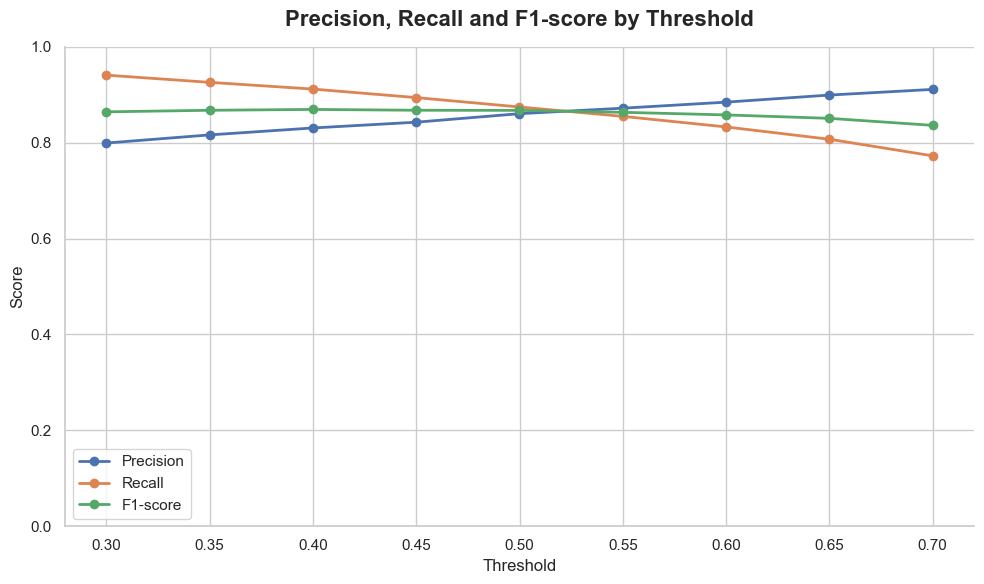

In [99]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-score"],
    marker="o",
    linewidth=2,
    label="F1-score"
)

plt.title("Precision, Recall and F1-score by Threshold", weight="bold", pad=15)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

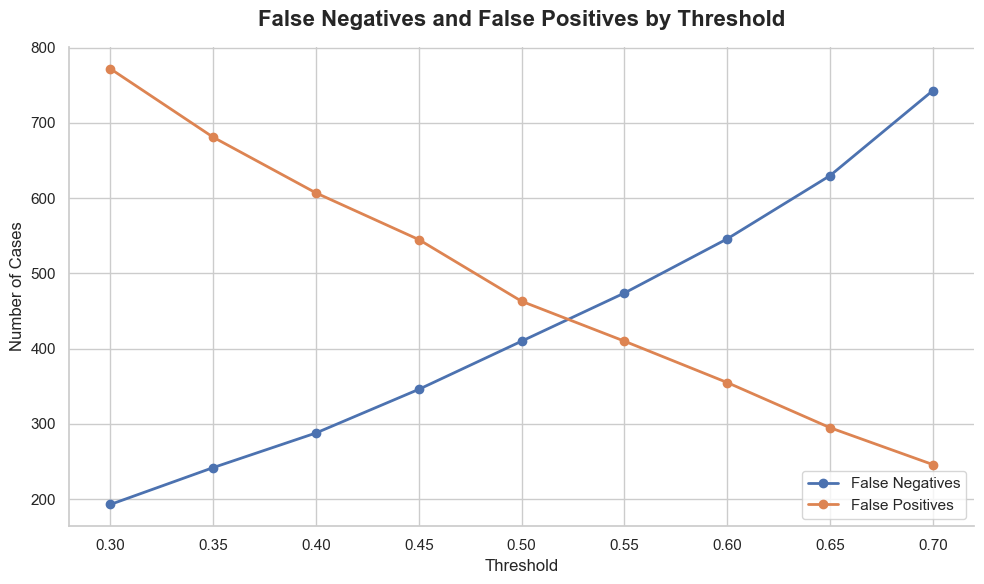

In [100]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False Negatives"],
    marker="o",
    linewidth=2,
    label="False Negatives"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False Positives"],
    marker="o",
    linewidth=2,
    label="False Positives"
)

plt.title("False Negatives and False Positives by Threshold", weight="bold", pad=15)
plt.xlabel("Threshold")
plt.ylabel("Number of Cases")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [101]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1-score"].idxmax()
]

best_f1_row

Threshold            0.400000
Accuracy             0.839634
Precision            0.830778
Recall               0.911873
F1-score             0.869438
False Negatives    288.000000
False Positives    607.000000
Name: 2, dtype: float64

In [102]:
high_recall_candidates = threshold_results_df[
    threshold_results_df["Precision"] >= 0.80
].sort_values(by="Recall", ascending=False)

high_recall_candidates

,Threshold,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
1,0.35,0.834617,0.816293,0.925949,0.867670,242,681
2,0.40,0.839634,0.830778,0.911873,0.869438,288,607
3,0.45,0.840351,0.842804,0.894125,0.867706,346,545
4,0.50,0.843576,0.860584,0.874541,0.867506,410,463
5,0.55,0.841605,0.872035,0.854957,0.863412,474,410
6,0.60,0.838559,0.884628,0.832925,0.857998,546,355
7,0.65,0.834259,0.899420,0.807222,0.850831,630,295
8,0.70,0.822792,0.911223,0.772644,0.836231,743,246


## Threshold Tuning Interpretation

The threshold tuning shows that the default threshold of 0.50 gives the best balanced performance. It has the highest F1-score and a good balance between precision and recall.

At threshold 0.50, the improved ANN model reaches a recall of around 0.899 and has 331 false negatives.

However, when the threshold is lowered to 0.35, recall increases to around 0.940 and the number of false negatives decreases to 196. This means that the model identifies more students in the depression class.

The trade-off is that false positives increase. At threshold 0.35, more students without depression are predicted as depressed.

In a mental health context, this trade-off is important. If the goal is a balanced model, threshold 0.50 is the best choice. If the goal is early risk detection and reducing missed risk cases, threshold 0.35 may be more useful.

For this project, the improved ANN with threshold 0.50 is selected as the final balanced model. However, threshold 0.35 is discussed as an alternative risk-detection setting.

In [103]:
final_model_summary = pd.DataFrame({
    "Model Setting": [
        "Improved ANN - Balanced threshold",
        "Improved ANN - Risk-detection threshold"
    ],
    "Threshold": [0.50, 0.35],
    "Use Case": [
        "Best overall balance between precision and recall",
        "Higher recall and fewer false negatives"
    ],
    "Precision": [0.843966, 0.802718],
    "Recall": [0.898715, 0.940024],
    "F1-score": [0.870480, 0.865962],
    "False Negatives": [331, 196],
    "False Positives": [543, 755]
})

final_model_summary

,Model Setting,Threshold,Use Case,Precision,Recall,F1-score,False Negatives,False Positives
0,Improved ANN - Balanced threshold,0.50,Best overall balance between precision and recall,0.843966,0.898715,0.870480,331,543
1,Improved ANN - Risk-detection threshold,0.35,Higher recall and fewer false negatives,0.802718,0.940024,0.865962,196,755


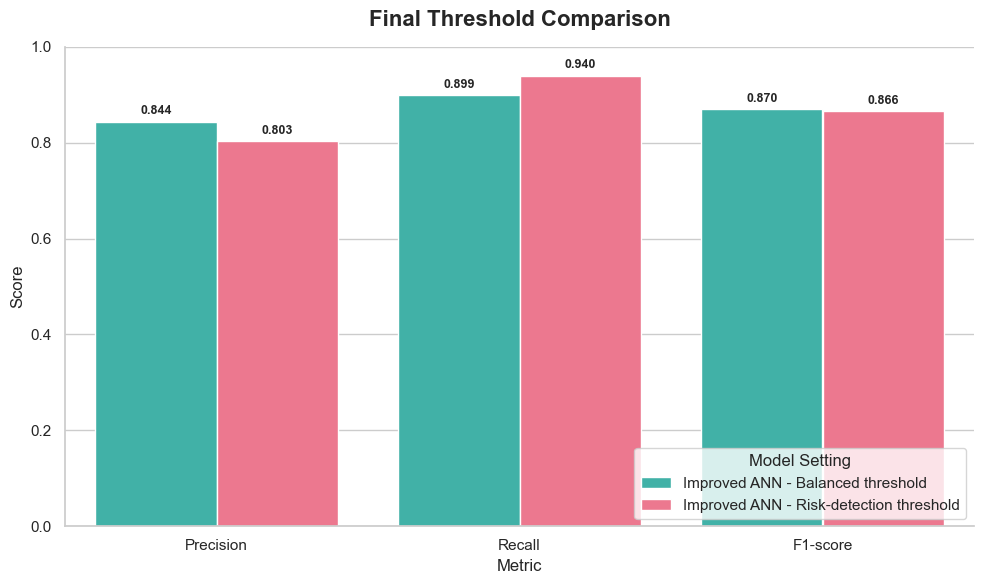

In [104]:
final_threshold_plot_df = final_model_summary.melt(
    id_vars=["Model Setting", "Threshold"],
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=final_threshold_plot_df,
    x="Metric",
    y="Score",
    hue="Model Setting",
    palette=["#2EC4B6", "#FF6584"]
)

plt.title("Final Threshold Comparison", weight="bold", pad=15)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

plt.legend(title="Model Setting", loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

# Manual Grid Search / Hyperparameter Tuning

In this section, I test different ANN architectures and training settings to find a better model.

The tested hyperparameters are:

- Number of neurons
- Dropout rate
- Learning rate
- Batch size

The goal is to compare different models and choose the best one based on validation performance and test performance.

In [105]:
def build_ann_model(input_dim, neurons_1=32, neurons_2=16, dropout_rate=0.2, learning_rate=0.001):
    """
    Build and compile an ANN model for binary classification.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(
            neurons_1,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(dropout_rate),
        
        layers.Dense(
            neurons_2,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        layers.Dropout(dropout_rate),
        
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [106]:
grid_params = [
    {"neurons_1": 32, "neurons_2": 16, "dropout_rate": 0.2, "learning_rate": 0.001, "batch_size": 32},
    {"neurons_1": 64, "neurons_2": 32, "dropout_rate": 0.2, "learning_rate": 0.001, "batch_size": 32},
    {"neurons_1": 64, "neurons_2": 32, "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 32},
    {"neurons_1": 128, "neurons_2": 64, "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 32},
    {"neurons_1": 64, "neurons_2": 32, "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 32},
    {"neurons_1": 64, "neurons_2": 32, "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 64},
]

grid_results = []

for i, params in enumerate(grid_params, start=1):
    print(f"\nTraining model {i}/{len(grid_params)}")
    print(params)
    
    temp_model = build_ann_model(
        input_dim=X_train_processed.shape[1],
        neurons_1=params["neurons_1"],
        neurons_2=params["neurons_2"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"]
    )
    
    temp_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
    
    temp_history = temp_model.fit(
        X_train_processed,
        y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=params["batch_size"],
        callbacks=[temp_early_stopping],
        verbose=0
    )
    
    y_temp_proba = temp_model.predict(X_test_processed, verbose=0).ravel()
    y_temp_pred = (y_temp_proba >= 0.50).astype(int)
    
    grid_results.append({
        "Model": f"Model {i}",
        "neurons_1": params["neurons_1"],
        "neurons_2": params["neurons_2"],
        "dropout_rate": params["dropout_rate"],
        "learning_rate": params["learning_rate"],
        "batch_size": params["batch_size"],
        "epochs_trained": len(temp_history.history["loss"]),
        "Accuracy": accuracy_score(y_test, y_temp_pred),
        "Precision": precision_score(y_test, y_temp_pred),
        "Recall": recall_score(y_test, y_temp_pred),
        "F1-score": f1_score(y_test, y_temp_pred),
        "ROC-AUC": roc_auc_score(y_test, y_temp_proba),
        "Average Precision": average_precision_score(y_test, y_temp_proba),
        "False Negatives": confusion_matrix(y_test, y_temp_pred)[1, 0],
        "False Positives": confusion_matrix(y_test, y_temp_pred)[0, 1]
    })

grid_results_df = pd.DataFrame(grid_results)

grid_results_df


Training model 1/6
{'neurons_1': 32, 'neurons_2': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}

Training model 2/6
{'neurons_1': 64, 'neurons_2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}

Training model 3/6
{'neurons_1': 64, 'neurons_2': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}

Training model 4/6
{'neurons_1': 128, 'neurons_2': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}

Training model 5/6
{'neurons_1': 64, 'neurons_2': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32}

Training model 6/6
{'neurons_1': 64, 'neurons_2': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}


,Model,neurons_1,neurons_2,dropout_rate,learning_rate,batch_size,epochs_trained,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision,False Negatives,False Positives
0,Model 1,32,16,0.2,0.0010,32,14,0.842860,0.858686,0.875765,0.867141,0.918185,0.936484,406,471
1,Model 2,64,32,0.2,0.0010,32,13,0.844472,0.864742,0.870563,0.867643,0.917787,0.936506,423,445
2,Model 3,64,32,0.3,0.0010,32,16,0.841785,0.859946,0.871787,0.865826,0.917846,0.936413,419,464
3,Model 4,128,64,0.3,0.0010,32,14,0.842501,0.860985,0.871787,0.866352,0.917784,0.936377,419,460
4,Model 5,64,32,0.3,0.0005,32,22,0.843756,0.860192,0.875459,0.867759,0.918003,0.936431,407,465
5,Model 6,64,32,0.3,0.0010,64,17,0.845010,0.859623,0.878825,0.869118,0.918098,0.936712,396,469


In [107]:
grid_results_df.sort_values(by="F1-score", ascending=False)

,Model,neurons_1,neurons_2,dropout_rate,learning_rate,batch_size,epochs_trained,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision,False Negatives,False Positives
5,Model 6,64,32,0.3,0.0010,64,17,0.845010,0.859623,0.878825,0.869118,0.918098,0.936712,396,469
4,Model 5,64,32,0.3,0.0005,32,22,0.843756,0.860192,0.875459,0.867759,0.918003,0.936431,407,465
1,Model 2,64,32,0.2,0.0010,32,13,0.844472,0.864742,0.870563,0.867643,0.917787,0.936506,423,445
0,Model 1,32,16,0.2,0.0010,32,14,0.842860,0.858686,0.875765,0.867141,0.918185,0.936484,406,471
3,Model 4,128,64,0.3,0.0010,32,14,0.842501,0.860985,0.871787,0.866352,0.917784,0.936377,419,460
2,Model 3,64,32,0.3,0.0010,32,16,0.841785,0.859946,0.871787,0.865826,0.917846,0.936413,419,464


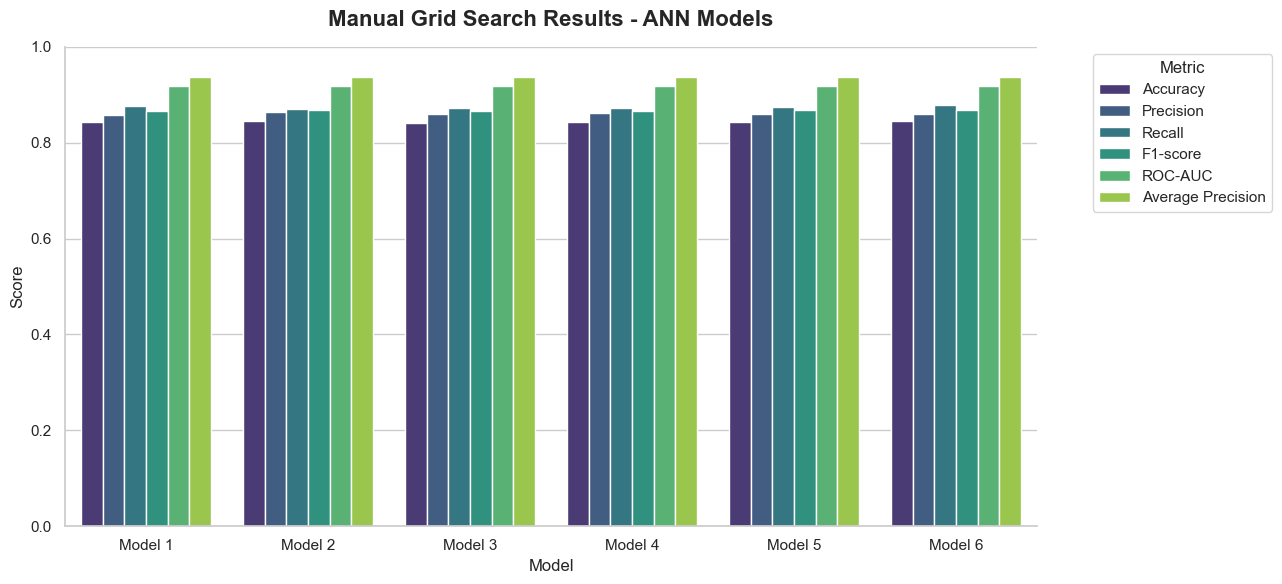

In [108]:
grid_plot_df = grid_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=grid_plot_df,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.title("Manual Grid Search Results - ANN Models", weight="bold", pad=15)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

In [109]:
best_grid_model_row = grid_results_df.loc[
    grid_results_df["F1-score"].idxmax()
]

best_grid_model_row

Model                 Model 6
neurons_1                  64
neurons_2                  32
dropout_rate              0.3
learning_rate           0.001
batch_size                 64
epochs_trained             17
Accuracy              0.84501
Precision            0.859623
Recall               0.878825
F1-score             0.869118
ROC-AUC              0.918098
Average Precision    0.936712
False Negatives           396
False Positives           469
Name: 5, dtype: object

In [110]:
best_recall_model_row = grid_results_df.loc[
    grid_results_df["Recall"].idxmax()
]

best_recall_model_row

Model                 Model 6
neurons_1                  64
neurons_2                  32
dropout_rate              0.3
learning_rate           0.001
batch_size                 64
epochs_trained             17
Accuracy              0.84501
Precision            0.859623
Recall               0.878825
F1-score             0.869118
ROC-AUC              0.918098
Average Precision    0.936712
False Negatives           396
False Positives           469
Name: 5, dtype: object

## Grid Search Results and Final Interpretation

The manual grid search tested six ANN configurations with different numbers of neurons, dropout rates, learning rates and batch sizes.

The best grid search model was Model 6. It reached slightly higher accuracy and ROC-AUC than the improved ANN model.

However, the improved ANN model still has higher recall than the best grid search model. Since this project focuses on student depression risk patterns, recall is especially important because it reduces the risk of missing students in the depression class.

Therefore, the final selected model is the improved ANN model with Dropout, L2 regularization and EarlyStopping.

The grid search was still valuable because it showed that different ANN architectures can give similar performance, and that a more complex or tuned model does not always give the best result for the project goal.

In [111]:
final_comparison = pd.DataFrame({
    "Model": [
        "Simple ANN",
        "Improved ANN",
        "Best Grid Search Model 6"
    ],
    "Accuracy": [
        0.829242,
        0.843397,
        0.844831
    ],
    "Precision": [
        0.845626,
        0.843966,
        0.856168
    ],
    "Recall": [
        0.866585,
        0.898715,
        0.883415
    ],
    "F1-score": [
        0.855977,
        0.870480,
        0.869578
    ],
    "ROC-AUC": [
        0.904164,
        0.917115,
        0.918094
    ],
    "False Negatives": [
        436,
        331,
        381
    ],
    "Final Decision": [
        "Baseline model",
        "Selected final model",
        "Strong but lower recall"
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,False Negatives,Final Decision
0,Simple ANN,0.829242,0.845626,0.866585,0.855977,0.904164,436,Baseline model
1,Improved ANN,0.843397,0.843966,0.898715,0.870480,0.917115,331,Selected final model
2,Best Grid Search Model 6,0.844831,0.856168,0.883415,0.869578,0.918094,381,Strong but lower recall


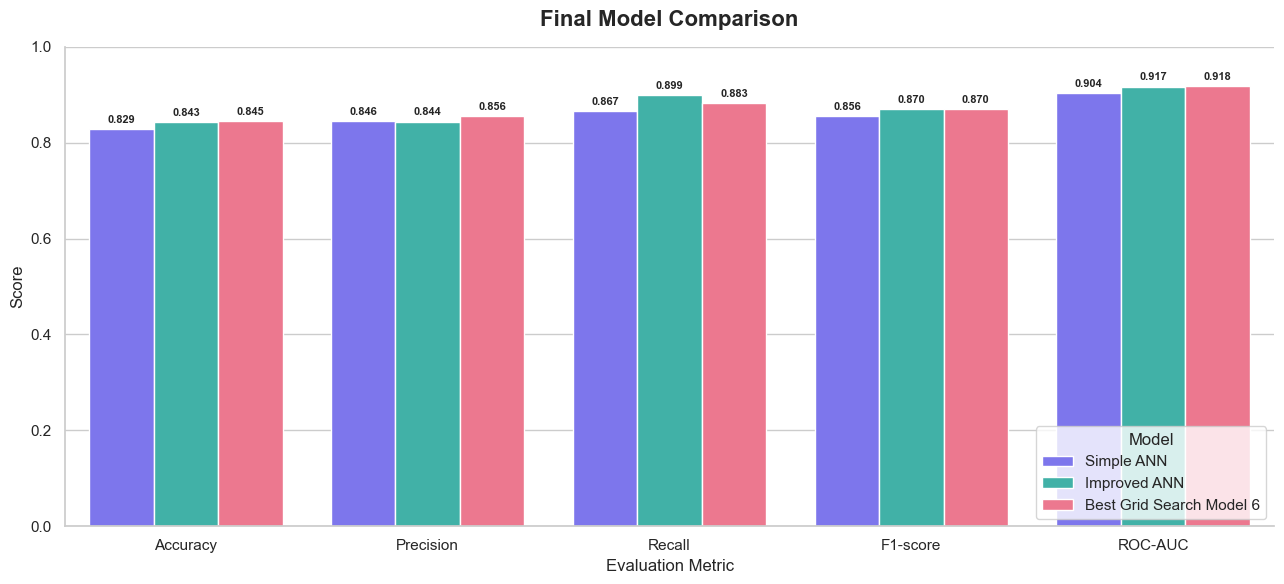

In [112]:
final_comparison_plot = final_comparison.melt(
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=final_comparison_plot,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#6C63FF", "#2EC4B6", "#FF6584"]
)

plt.title("Final Model Comparison", weight="bold", pad=15)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8,
        fontweight="bold"
    )

plt.legend(title="Model", loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

# Final Conclusion

This project used the Student Depression Dataset to build and evaluate ANN models for binary classification.

The EDA showed that several variables are related to depression in the dataset, especially academic pressure, financial stress, work/study hours, sleep duration and history of suicidal thoughts.

A simple ANN model was first built as a baseline. It performed well, but the training curves showed signs of overfitting.

To improve the model, a second ANN model was built using Dropout, L2 regularization and EarlyStopping. This improved the model’s generalization and gave better performance than the baseline model.

The improved ANN model achieved better accuracy, recall, F1-score, ROC-AUC and Average Precision compared to the simple ANN model. It also reduced the number of false negatives.

Threshold tuning showed that the default threshold of 0.50 gives a good balanced model, while a lower threshold can be considered if the goal is early risk detection and reducing false negatives.

Manual Grid Search tested several different ANN architectures. The best grid search model performed well, but the improved ANN model was still selected as the final model because it had stronger recall, which is important in this mental health context.

The final selected model is therefore the Improved ANN model with Dropout, L2 regularization and EarlyStopping.

From a business and social value perspective, this type of model could help schools and universities better understand risk patterns related to student mental health. However, because the dataset contains sensitive mental health information, the model should only be used as a supportive analytical tool and never as a medical diagnosis system.

In [113]:
from pathlib import Path

Path("../../models").mkdir(parents=True, exist_ok=True)

In [114]:
import joblib

# Save final selected model
improved_model.save("../../models/mahtab_improved_ann_model.keras")

# Save preprocessor
joblib.dump(preprocessor, "../../models/mahtab_preprocessor.pkl")

print("Final model and preprocessor saved successfully!")

Final model and preprocessor saved successfully!


Problem → Data → EDA patterns → Simple ANN → Improved ANN → Grid Search → Final model → Business value → Ethics

In [115]:
from sklearn import set_config
import joblib

set_config(display="diagram")

loaded_preprocessor = joblib.load("../../models/mahtab_preprocessor.pkl")
loaded_preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [116]:
feature_names = loaded_preprocessor.get_feature_names_out()

feature_names_df = pd.DataFrame({
    "Feature": feature_names
})

feature_names_df

,Feature
0,num__Age
1,num__Academic Pressure
2,num__Work Pressure
3,num__CGPA
4,num__Study Satisfaction
...,...
106,cat__Degree_PhD
107,cat__Have you ever had suicidal thoughts ?_No
108,cat__Have you ever had suicidal thoughts ?_Yes
109,cat__Family History of Mental Illness_No


In [117]:
import sys
print(sys.executable)

c:\Users\mahta\anaconda3\python.exe


In [118]:
import sys
!{sys.executable} -m pip install pydot

In [119]:
import pydot
print("pydot works!")

pydot works!


In [120]:
from tensorflow import keras
import joblib
import shutil

In [121]:
loaded_model = keras.models.load_model("../../models/mahtab_improved_ann_model.keras")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,845 (108.77 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,564 (72.52 KB)

In [122]:
import shutil
print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


In [123]:
import os
import shutil

graphviz_path = r"C:\Program Files\Graphviz\bin"
os.environ["PATH"] += os.pathsep + graphviz_path

print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


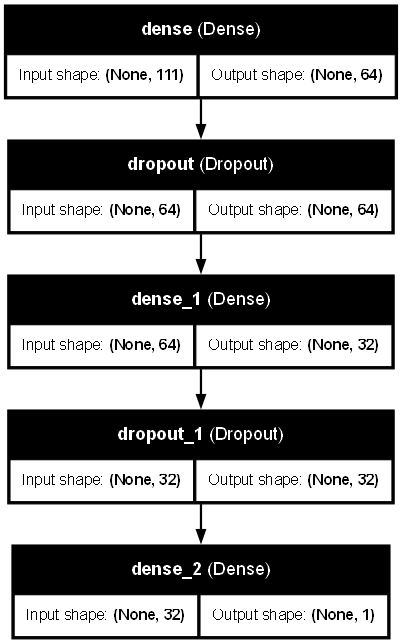

In [124]:
from tensorflow import keras

keras.utils.plot_model(
    loaded_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)

The final ANN model receives 111 processed input features after preprocessing.  
It has two hidden Dense layers with Dropout regularization and one output neuron with sigmoid activation for binary classification.